In [4]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 18.3 MB/s eta 0:00:00


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("cerenakmese/plantvillage-dataset-in-yolo-format")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/cerenakmese/plantvillage-dataset-in-yolo-format/versions/1


In [ ]:
yaml_path = "/root/.cache/kagglehub/datasets/cerenakmese/plantvillage-dataset-in-yolo-format/versions/1/yolo_dataset/dataset.yaml"

correct_yaml = f"""
path: /root/.cache/kagglehub/datasets/cerenakmese/plantvillage-dataset-in-yolo-format/versions/1/yolo_dataset
train: images/train
val: images/val
test: images/test

nc: 38
names:
- Apple___Apple_scab
- Apple___Black_rot
- Apple___Cedar_apple_rust
- Apple___healthy
- Blueberry___healthy
- Cherry_(including_sour)___Powdery_mildew
- Cherry_(including_sour)___healthy
- Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
- Corn_(maize)__Common_rust
- Corn_(maize)___Northern_Leaf_Blight
- Corn_(maize)___healthy
- Grape___Black_rot
- Grape__Esca(Black_Measles)
- Grape__Leaf_blight(Isariopsis_Leaf_Spot)
- Grape___healthy
- Orange__Haunglongbing(Citrus_greening)
- Peach___Bacterial_spot
- Peach___healthy
- Pepper,bell__Bacterial_spot
- Pepper,bell__healthy
- Potato___Early_blight
- Potato___Late_blight
- Potato___healthy
- Raspberry___healthy
- Soybean___healthy
- Squash___Powdery_mildew
- Strawberry___Leaf_scorch
- Strawberry___healthy
- Tomato___Bacterial_spot
- Tomato___Early_blight
- Tomato___Late_blight
- Tomato___Leaf_Mold
- Tomato___Septoria_leaf_spot
- Tomato___Spider_mites Two-spotted_spider_mite
- Tomato___Target_Spot
- Tomato___Tomato_Yellow_Leaf_Curl_Virus
- Tomato___Tomato_mosaic_virus
- Tomato___healthy
"""

with open(yaml_path, "w") as f:
    f.write(correct_yaml)

print("Dataset YAML updated successfully!")

Dataset YAML updated successfully!


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
SAVE_DIR = "/content/drive/MyDrive/YOLO_PlantVillage"

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data=yaml_path,
    epochs=20,
    imgsz=640,
    batch=16,
    project=SAVE_DIR,   # ← VERY IMPORTANT
    name="train_v1"
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.228 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/root/.cache/kagglehub/datasets/cerenakmese/plantvillage-dataset-in-yolo-format/versions/1/yolo_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None

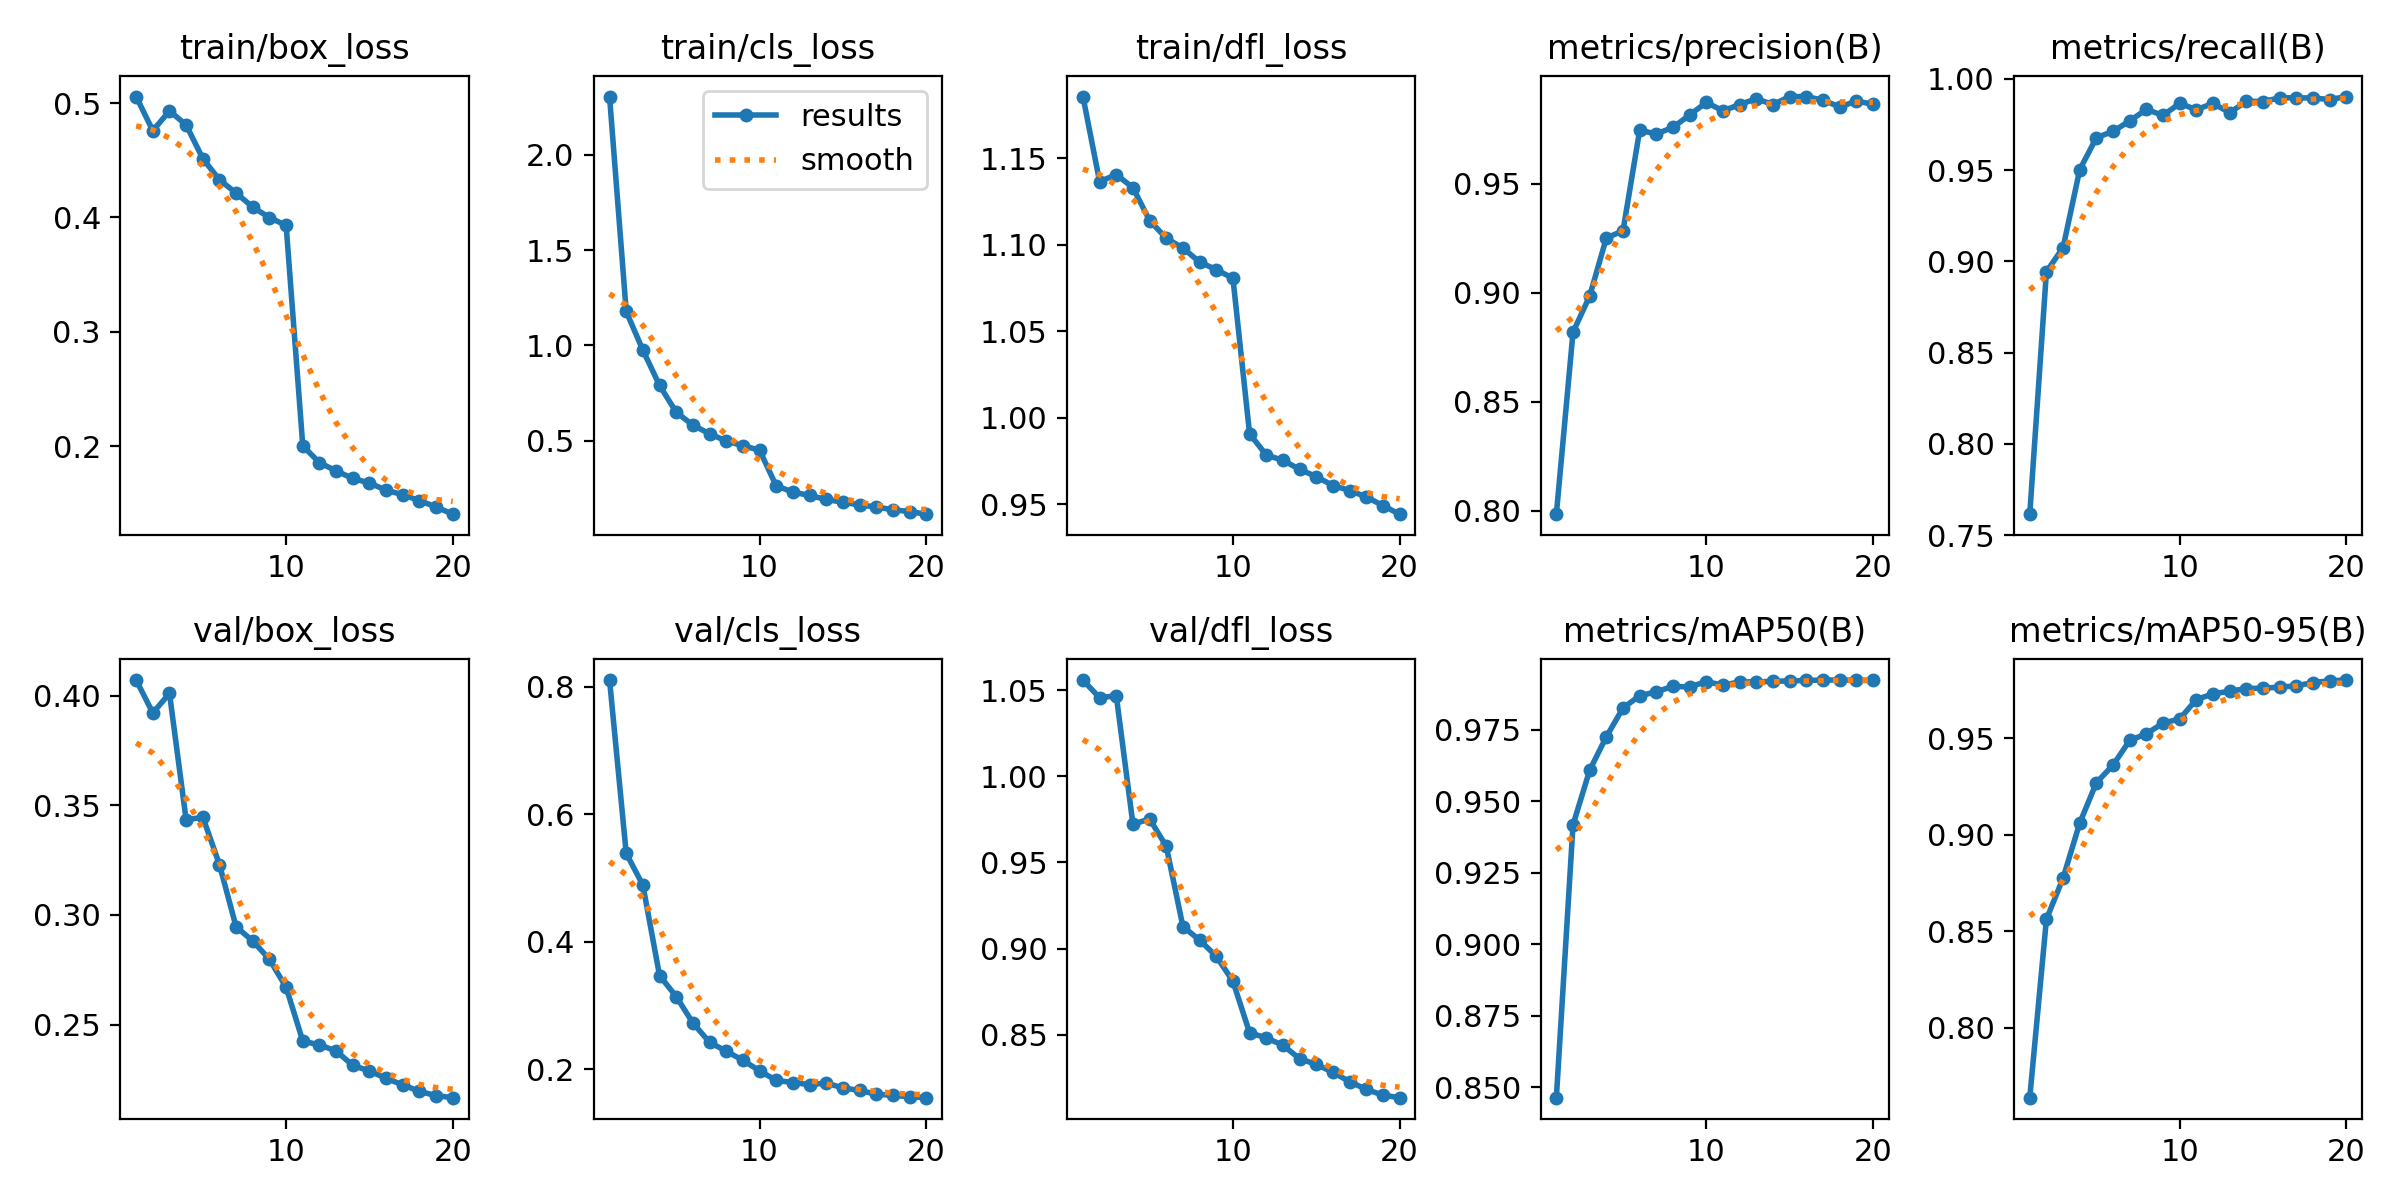

In [ ]:
from IPython.display import Image
Image(filename=SAVE_DIR + "/train_v1/results.png")

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/YOLO_PlantVillage/train_v1/weights/best.pt")

results = model.predict(
    source="/test_leaf.jpeg",
    save=True,
    imgsz=640,
    conf=0.5
)


image 1/1 /test_leaf.jpeg: 640x640 1 Apple___Apple_scab, 7.4ms
Speed: 11.3ms preprocess, 7.4ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


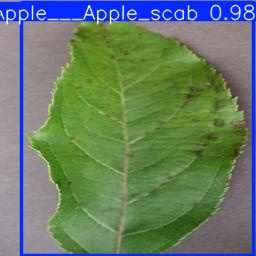

In [ ]:
from IPython.display import Image
Image(filename="runs/detect/predict/test_leaf.jpg")

In [ ]:
import pandas as pd
df = pd.read_csv(SAVE_DIR + "/train_v1/results.csv")
df.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
15,16,12261.8,0.16143,0.16203,0.96092,0.99008,0.98961,0.99219,0.97646,0.22539,0.16709,0.82818,0.002575,0.002575,0.002575
16,17,12984.0,0.15741,0.15088,0.95804,0.98841,0.98955,0.99232,0.97718,0.22248,0.16136,0.82274,0.002080,0.002080,0.002080
17,18,13722.2,0.15229,0.13649,0.95437,0.98535,0.98949,0.99231,0.97888,0.21950,0.15947,0.81828,0.001585,0.001585,0.001585
18,19,14452.5,0.14676,0.12686,0.94931,0.98791,0.98861,0.99225,0.97979,0.21753,0.15739,0.81490,0.001090,0.001090,0.001090
19,20,15193.5,0.14042,0.11314,0.94436,0.98663,0.99026,0.99221,0.98017,0.21662,0.15581,0.81345,0.000595,0.000595,0.000595


In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/YOLO_PlantVillage/train_v1/weights/best.pt")

results = model.predict(
    source="/image (1).JPG",
    save=True,
    imgsz=640,
    conf=0.5
)


image 1/1 /image (1).JPG: 640x640 1 Apple___healthy, 7.6ms
Speed: 3.4ms preprocess, 7.6ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict2


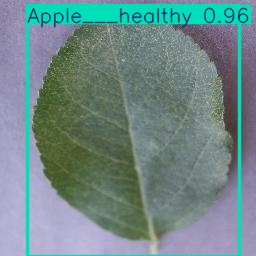

In [ ]:
from IPython.display import Image
Image(filename="/content/runs/detect/predict2/image (1).jpg")

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/YOLO_PlantVillage/train_v1/weights/best.pt")

results = model.predict(
    source="/tomato_early_blight.jpeg",
    save=True,
    imgsz=640,
    conf=0.5
)


image 1/1 /tomato_early_blight.jpeg: 640x480 1 Tomato___Early_blight, 7.1ms
Speed: 1.9ms preprocess, 7.1ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict4


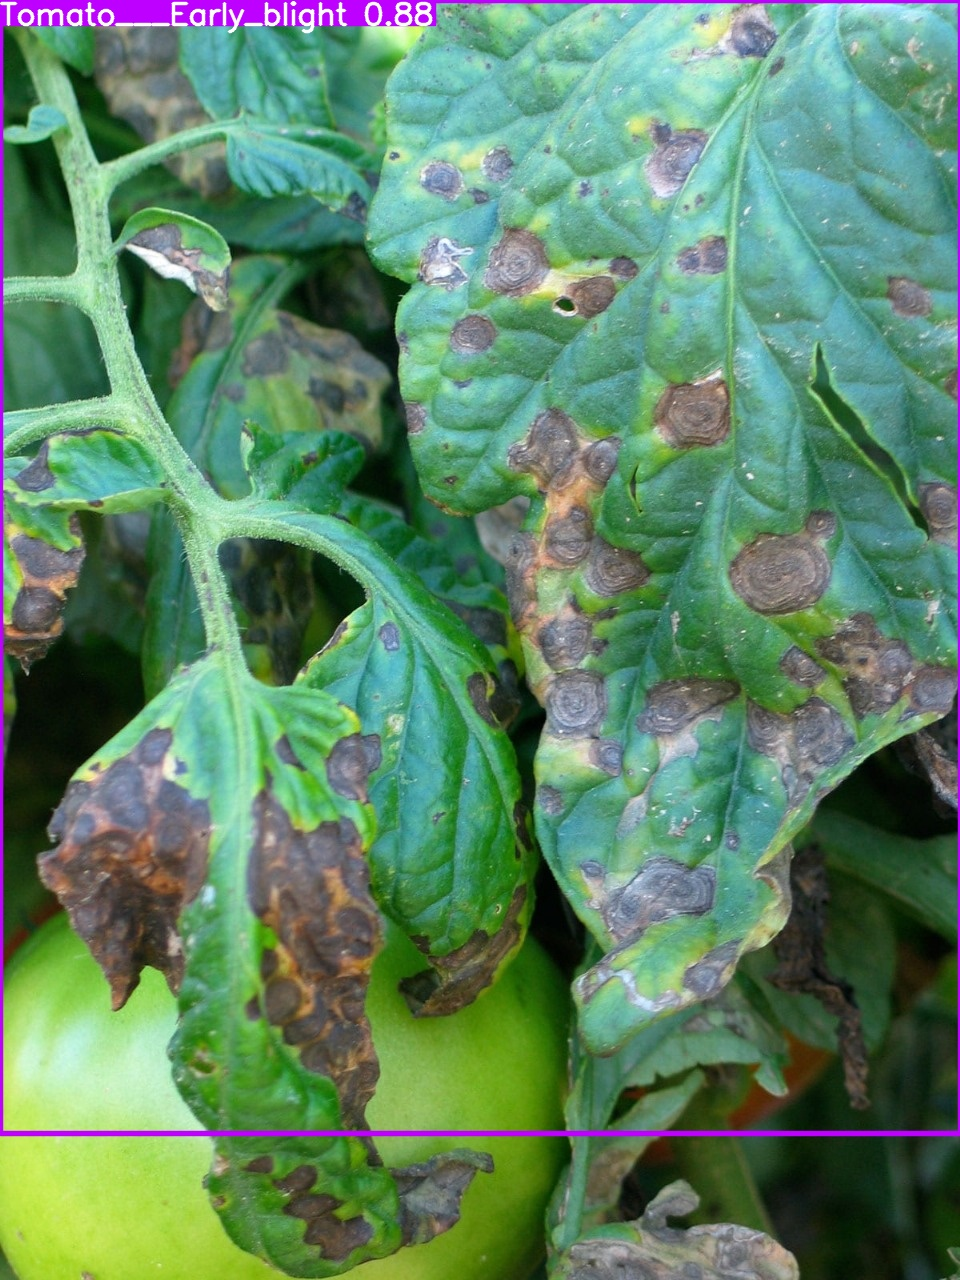

In [ ]:
from IPython.display import Image
Image(filename="/content/runs/detect/predict4/tomato_early_blight.jpg")

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/YOLO_PlantVillage/train_v1/weights/best.pt")

results = model.predict(
    source="/tomato_early_blight(1).jpeg",
    save=True,
    imgsz=640,
    conf=0.5
)


image 1/1 /tomato_early_blight(1).jpeg: 608x640 (no detections), 38.1ms
Speed: 2.8ms preprocess, 38.1ms inference, 0.5ms postprocess per image at shape (1, 3, 608, 640)
Results saved to /content/runs/detect/predict5


In [ ]:
!mkdir -p /content/drive/MyDrive/Datasets/PlantDoc


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving PlantDoc.v2-resize-100x100.yolov8 (1).zip to PlantDoc.v2-resize-100x100.yolov8 (1).zip


In [ ]:
!mv "PlantDoc.v2-resize-100x100.yolov8 (1).zip" /content/drive/MyDrive/Datasets/PlantDoc/


In [ ]:
!ls "/content/drive/MyDrive"


 1602-22-737-096
'1602-22-737-096(EFE assignment -2).pdf'
'1602-22-737-096(EFE assignment 3).pdf'
'1602-22-737-096(Introduction to programming in C).pdf'
'Adobe Scan 04-Mar-2025.pdf'
'AIML lab(1602-22-737-096)'
'BURRA NANDHINI REDDY.gdoc'
'Burra Nandhini Reddy_Resume (1).pdf'
'Burra Nandhini Reddy_Resume (2).pdf'
'Burra Nandhini Reddy_Resume (3).pdf'
'Burra Nandhini Reddy_Resume (4).pdf'
'Burra Nandhini Reddy_Resume.pdf'
 Classroom
'Colab Notebooks'
'college id(back).jpeg'
'college id(front).jpeg'
 Datasets
'industrial Visit.docx'
'math lab'
'Nandhini Reddy Burra_Resume (1).pdf'
'Nandhini Reddy Burra_Resume.pdf'
'Nandhini Reddy resume.gdoc'
'Nandhini Reddy resume.pdf'
 Nandhu-Aadhar.pdf
'Nandhu resume(S&P).pdf'
'sem6(reults).jpg'
 YOLO_PlantVillage


In [ ]:
!unzip "/content/drive/MyDrive/Datasets/PlantDoc/PlantDoc.v2-resize-100x100.yolov8 (1).zip" -d "/content/drive/MyDrive/Datasets/PlantDoc/"

Streaming output truncated to the last 5000 lines.
 extracting: /content/drive/MyDrive/Datasets/PlantDoc/test/images/depositphotos_3786198-Peach-leaf_jpg.rf.4c1ad99b5e5d840aa5740ae64906ca2d.jpg  
 extracting: /content/drive/MyDrive/Datasets/PlantDoc/test/images/depositphotos_6898486-stock-photo-grape-leaves_jpg.rf.4d304f7e9de4b2e8339466c41153974c.jpg  
 extracting: /content/drive/MyDrive/Datasets/PlantDoc/test/images/dsc_8148cs_jpg.rf.5dd14e14d779e10ba61232c36a18b52c.jpg  
 extracting: /content/drive/MyDrive/Datasets/PlantDoc/test/images/dscn3175_jpg.rf.cfda0a26421a1bf4b927a4d236897b25.jpg  
 extracting: /content/drive/MyDrive/Datasets/PlantDoc/test/images/dscn6689_jpg.rf.0ca73287efd4e65b650dc695db284a1a.jpg  
 extracting: /content/drive/MyDrive/Datasets/PlantDoc/test/images/e33155_jpg.rf.56aef74d902338d81dcb96381edb5a23.jpg  
 extracting: /content/drive/MyDrive/Datasets/PlantDoc/test/images/e52bbb9a08ede2948ba0c006f02fe7b053ad7831d1df6_1260x1260_jpg.rf.cdc6c6cbe37f86c3acc3bb2d3be898f7

In [ ]:
with open("/content/drive/MyDrive/Datasets/PlantDoc/data.yaml") as f:
    print(f.read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 30
names: ['Apple Scab Leaf', 'Apple leaf', 'Apple rust leaf', 'Bell_pepper leaf spot', 'Bell_pepper leaf', 'Blueberry leaf', 'Cherry leaf', 'Corn Gray leaf spot', 'Corn leaf blight', 'Corn rust leaf', 'Peach leaf', 'Potato leaf early blight', 'Potato leaf late blight', 'Potato leaf', 'Raspberry leaf', 'Soyabean leaf', 'Soybean leaf', 'Squash Powdery mildew leaf', 'Strawberry leaf', 'Tomato Early blight leaf', 'Tomato Septoria leaf spot', 'Tomato leaf bacterial spot', 'Tomato leaf late blight', 'Tomato leaf mosaic virus', 'Tomato leaf yellow virus', 'Tomato leaf', 'Tomato mold leaf', 'Tomato two spotted spider mites leaf', 'grape leaf black rot', 'grape leaf']

roboflow:
  workspace: joseph-nelson
  project: plantdoc
  version: 2
  license: CC BY 4.0
  url: https://universe.roboflow.com/joseph-nelson/plantdoc/dataset/2


In [ ]:
%%writefile /content/drive/MyDrive/Datasets/PlantDoc/plantdoc.yaml
path: /content/drive/MyDrive/Datasets/PlantDoc

train: train/images
val: val/images
test: test/images

nc: 30

names:
  0: Apple Scab Leaf
  1: Apple leaf
  2: Apple rust leaf
  3: Bell_pepper leaf spot
  4: Bell_pepper leaf
  5: Blueberry leaf
  6: Cherry leaf
  7: Corn Gray leaf spot
  8: Corn leaf blight
  9: Corn rust leaf
  10: Peach leaf
  11: Potato leaf early blight
  12: Potato leaf late blight
  13: Potato leaf
  14: Raspberry leaf
  15: Soyabean leaf
  16: Soybean leaf
  17: Squash Powdery mildew leaf
  18: Strawberry leaf
  19: Tomato Early blight leaf
  20: Tomato Septoria leaf spot
  21: Tomato leaf bacterial spot
  22: Tomato leaf late blight
  23: Tomato leaf mosaic virus
  24: Tomato leaf yellow virus
  25: Tomato leaf
  26: Tomato mold leaf
  27: Tomato two spotted spider mites leaf
  28: grape leaf black rot
  29: grape leaf


Writing /content/drive/MyDrive/Datasets/PlantDoc/plantdoc.yaml


In [ ]:
!mv "/content/drive/MyDrive/Datasets/PlantDoc/test" "/content/drive/MyDrive/Datasets/PlantDoc/val"


In [ ]:
!ls "/content/drive/MyDrive/Datasets/PlantDoc"


 data.yaml				      README.dataset.txt    val
'PlantDoc.v2-resize-100x100.yolov8 (1).zip'   README.roboflow.txt
 plantdoc.yaml				      train


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")   # or yolov8n for lightweight

model.train(
    data="/content/drive/MyDrive/Datasets/PlantDoc/plantdoc.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    project="/content/drive/MyDrive/YOLO_Trainings",
    name="PlantDoc_v1"
)


Ultralytics 8.3.230 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Datasets/PlantDoc/plantdoc.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=PlantDoc_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, per

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 12, 13, 14, 15, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 28, 29])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f453382dee0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.0

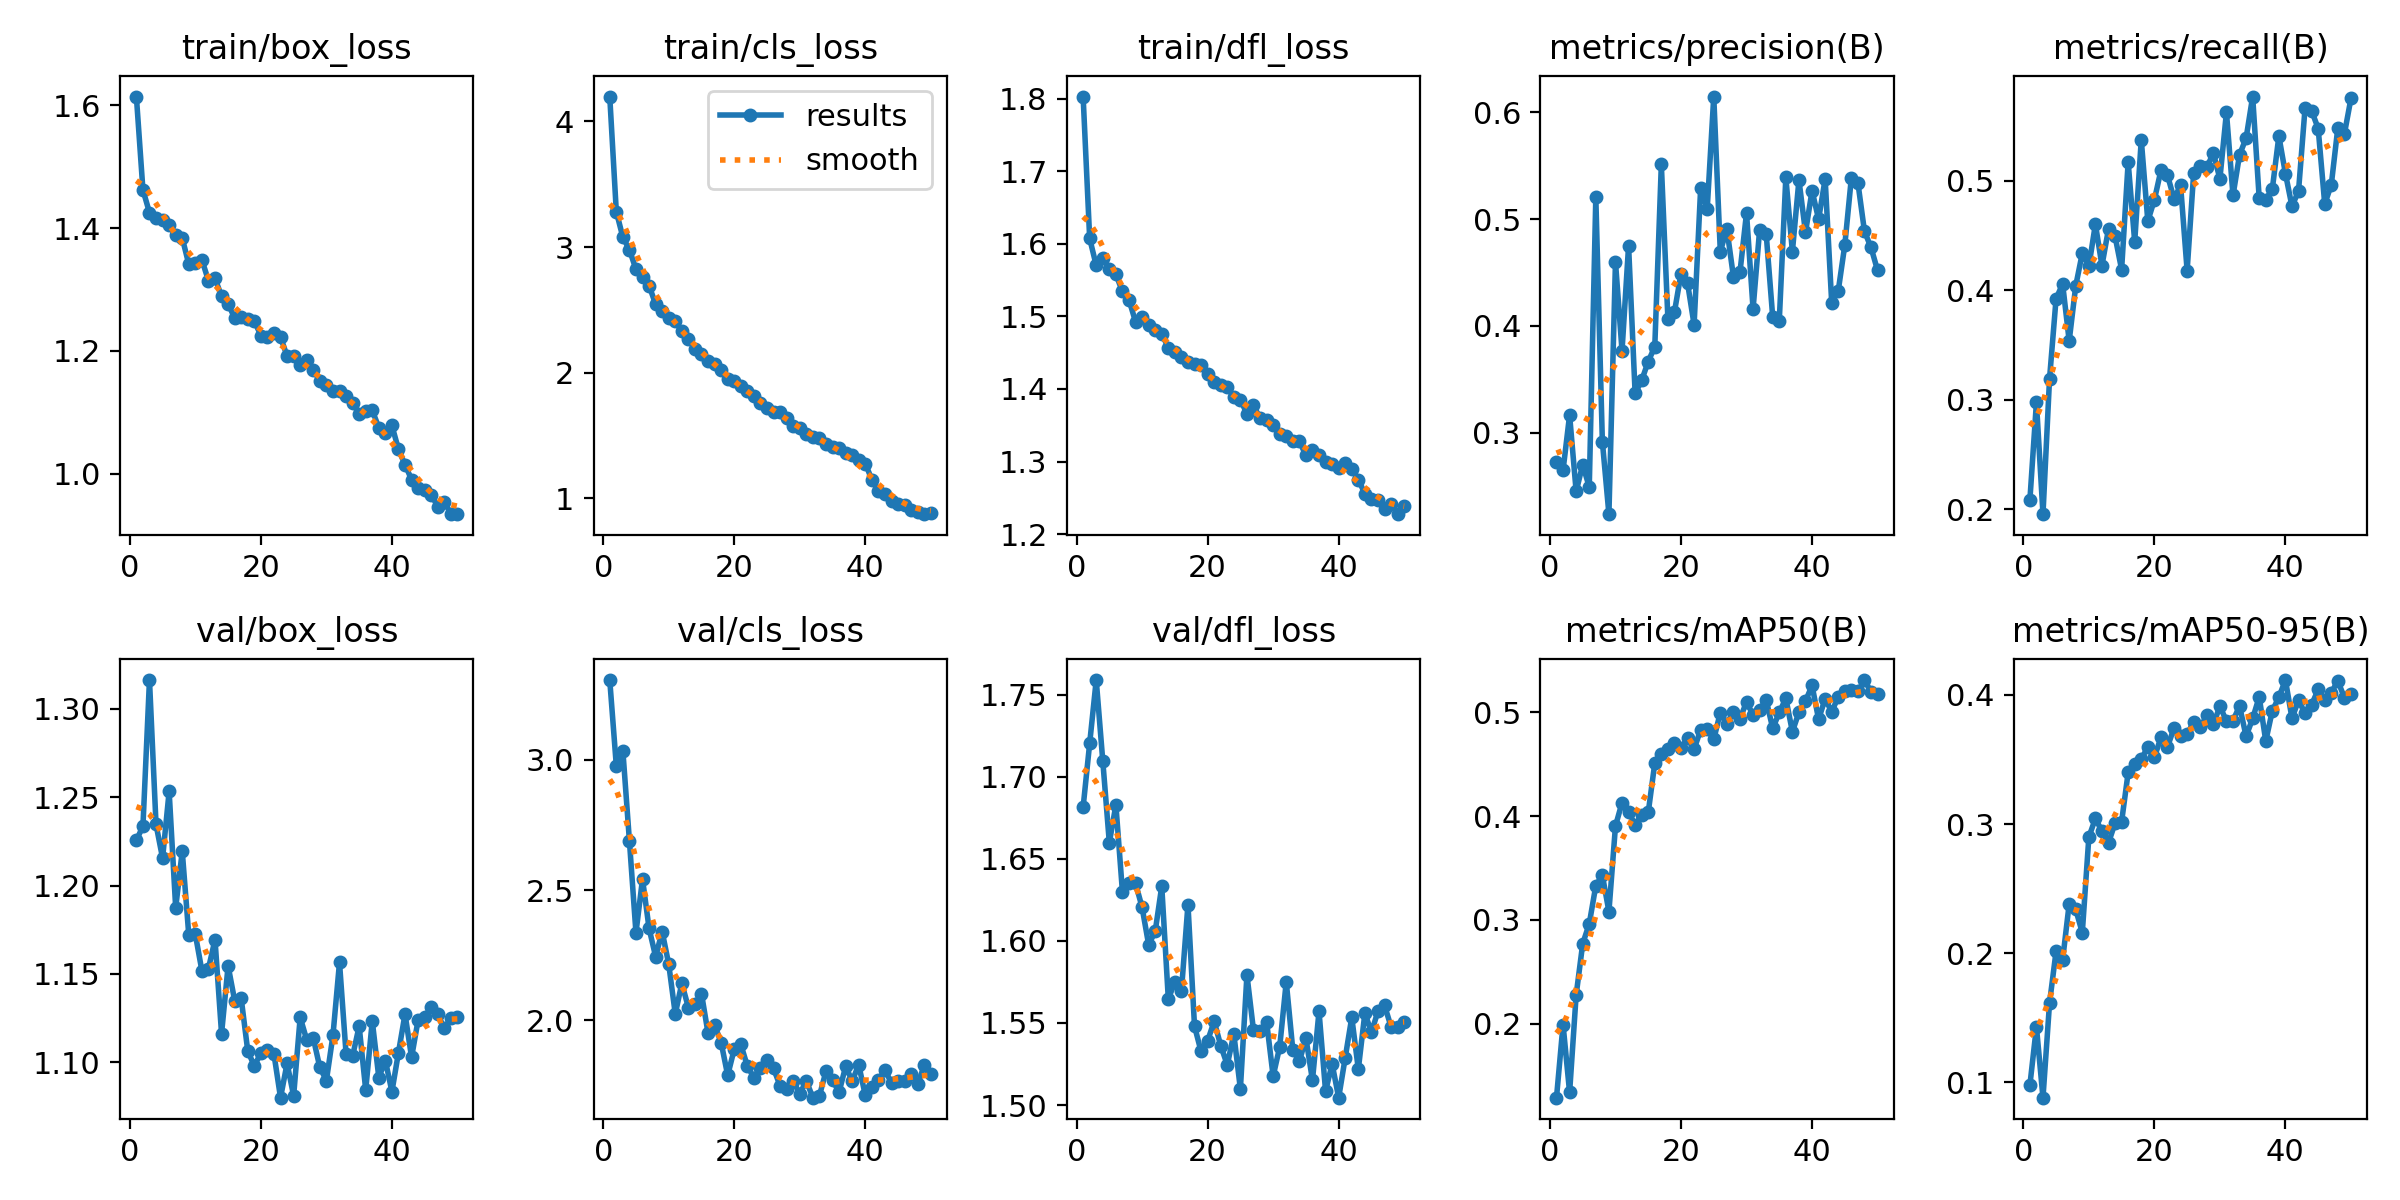

In [ ]:
from IPython.display import Image
Image(filename="/content/drive/MyDrive/YOLO_Trainings/PlantDoc_v1/results.png")


In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/YOLO_PlantVillage/train_v1/weights/best.pt")

results = model.predict(
    source="//content/tomato early_blight1.jpg",
    save=True,
    imgsz=640,
    conf=0.5
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

image 1/1 //content/tomato early_blight1.jpg: 640x480 1 Tomato___Late_blight, 64.1ms
Speed: 11.9ms preprocess, 64.1ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict


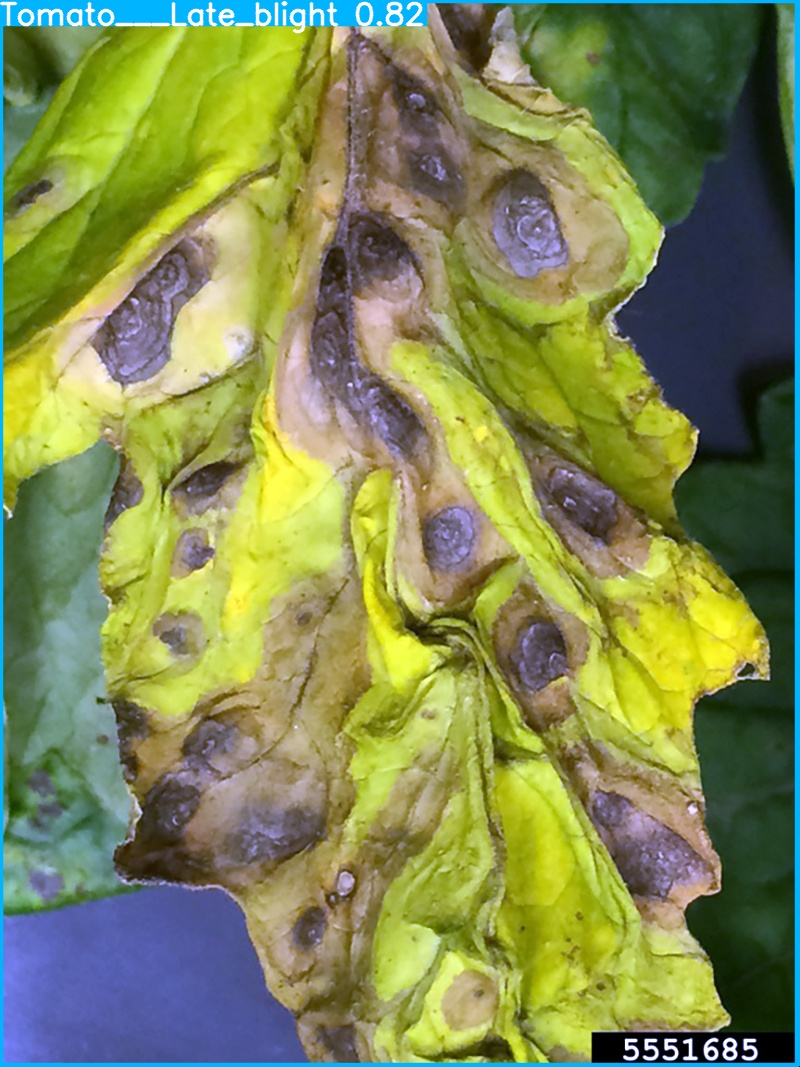

In [ ]:
from IPython.display import Image
Image(filename="/content/runs/detect/predict/tomato early_blight1.jpg")

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/YOLO_Trainings/PlantDoc_v1/weights/best.pt")

results = model.predict(
    source="//content/tomato early_blight1.jpg",
    save=True,
    imgsz=640,
    conf=0.5
)


image 1/1 //content/tomato early_blight1.jpg: 640x480 (no detections), 36.1ms
Speed: 3.3ms preprocess, 36.1ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict2


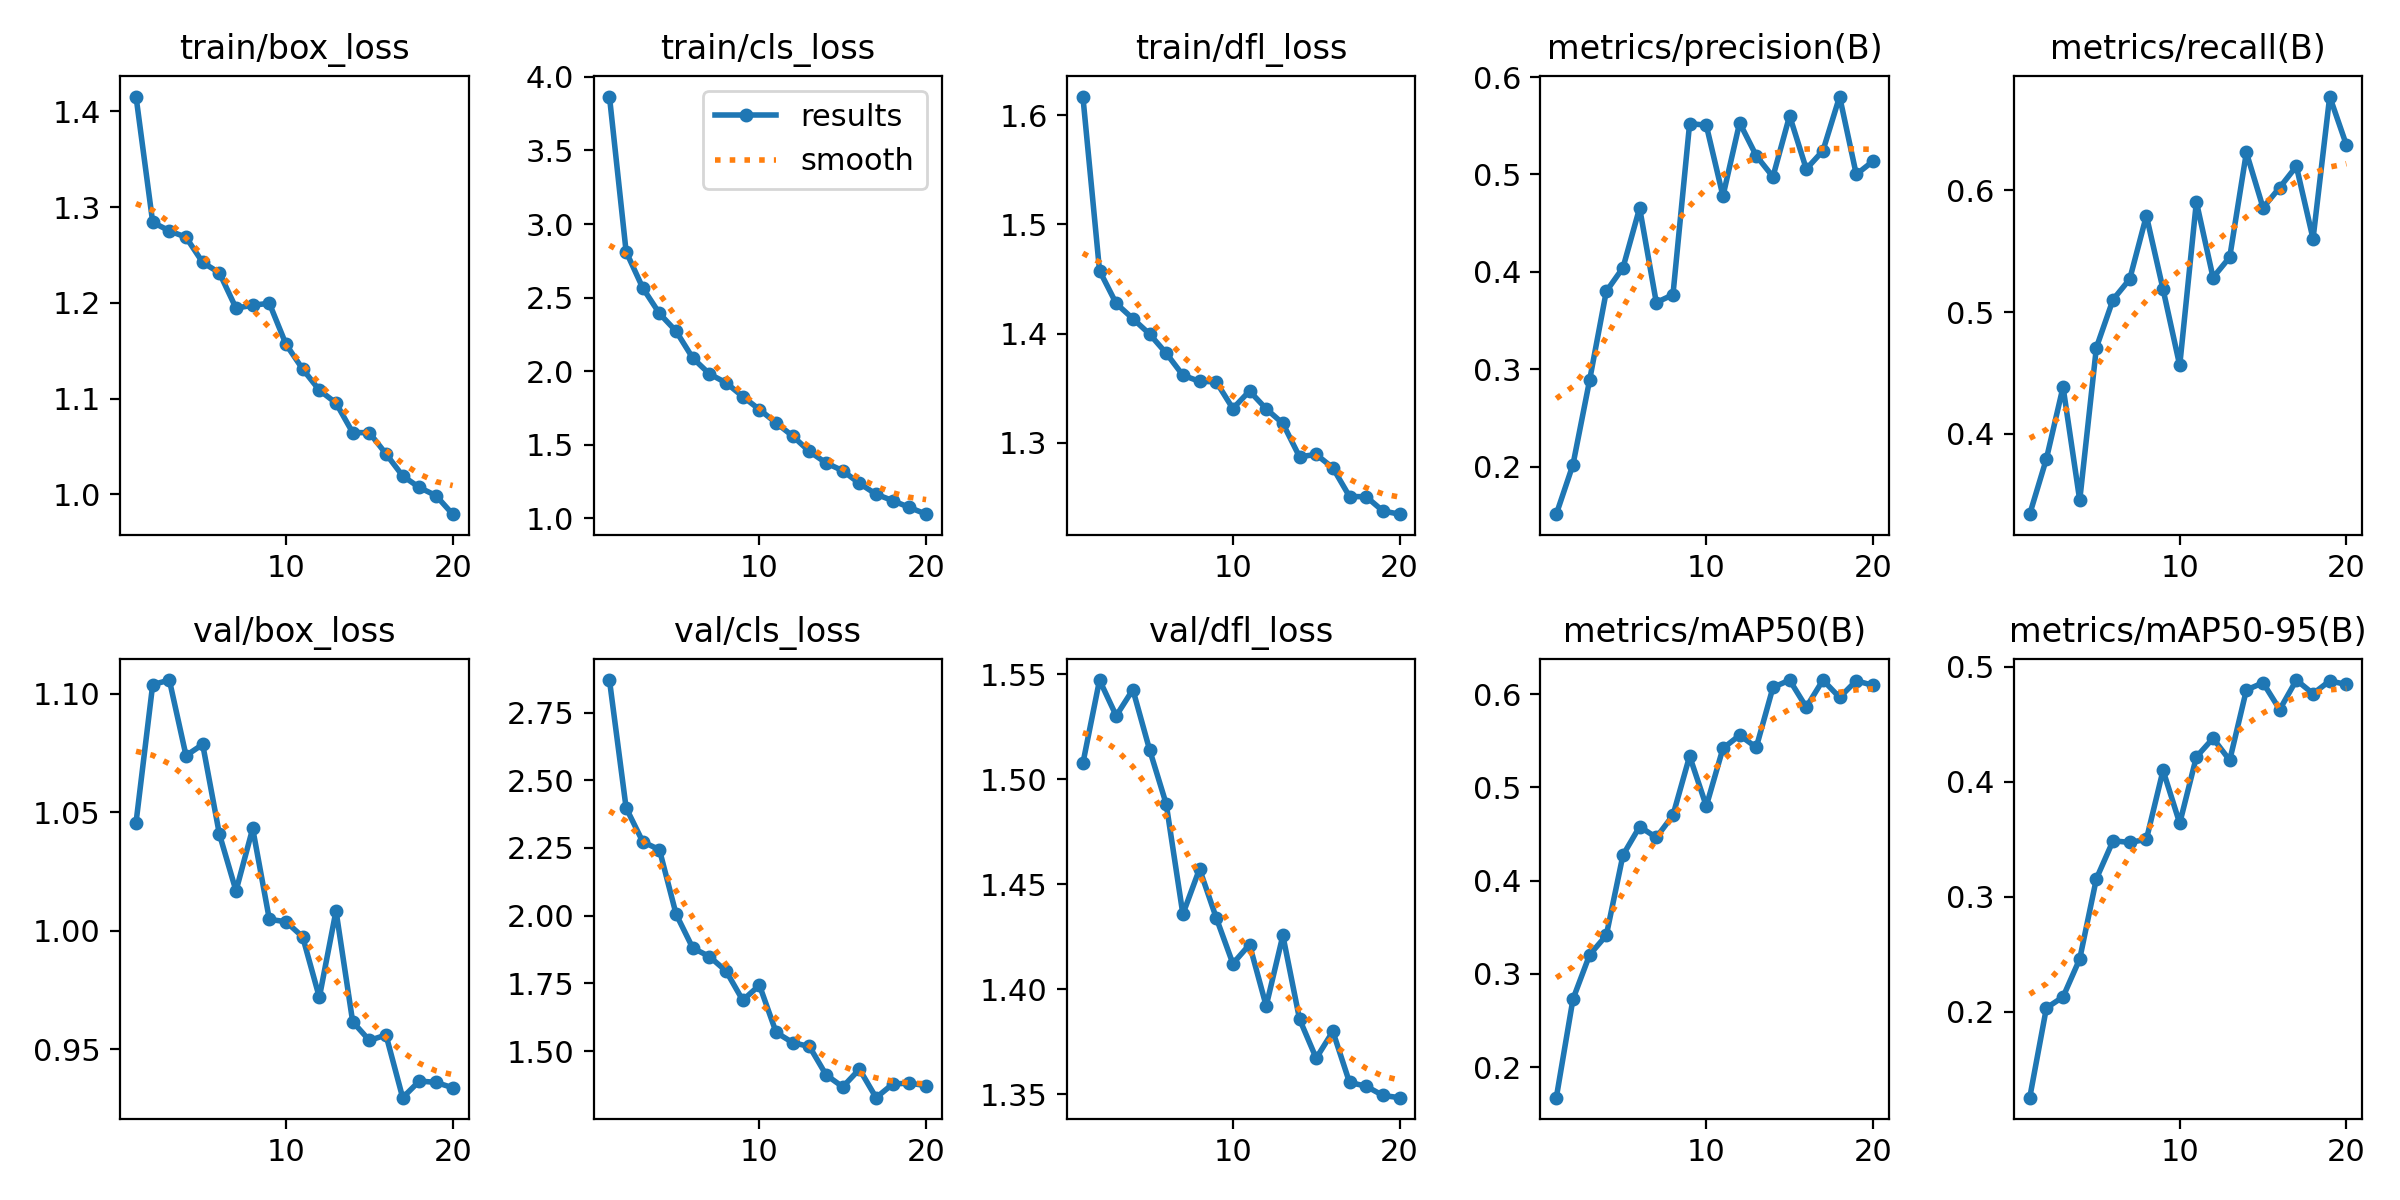

In [ ]:
from IPython.display import Image
Image(filename="/content/drive/MyDrive/YOLO_Trainings1/PlantDoc_v13/results.png")


In [7]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/YOLO_Trainings1/PlantDoc_v13/weights/best.pt")

results = model.predict(
    source="//content/tomato early_blight1.jpg",
    save=True,
    imgsz=640,
    conf=0.5
)


image 1/1 //content/tomato early_blight1.jpg: 640x480 1 Tomato Early blight leaf, 469.1ms
Speed: 4.7ms preprocess, 469.1ms inference, 3.0ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict2


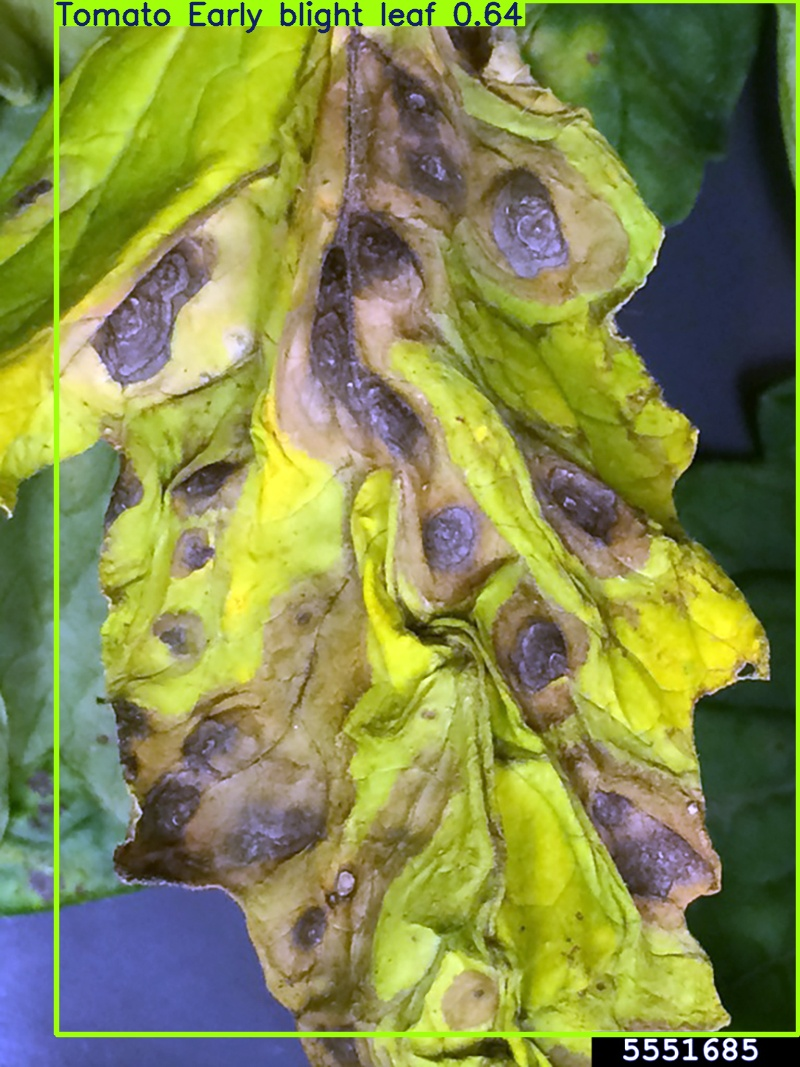

In [8]:
from IPython.display import Image
Image(filename="/content/runs/detect/predict2/tomato early_blight1.jpg")

In [6]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/YOLO_PlantVillage/train_v1/weights/best.pt")

results = model.predict(
    source="/content/Early-blight-potato-canopy.jpg",
    save=True,
    imgsz=640,
    conf=0.5
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

image 1/1 /content/Early-blight-potato-canopy.jpg: 448x640 1 Tomato___Early_blight, 456.8ms
Speed: 16.5ms preprocess, 456.8ms inference, 33.9ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict


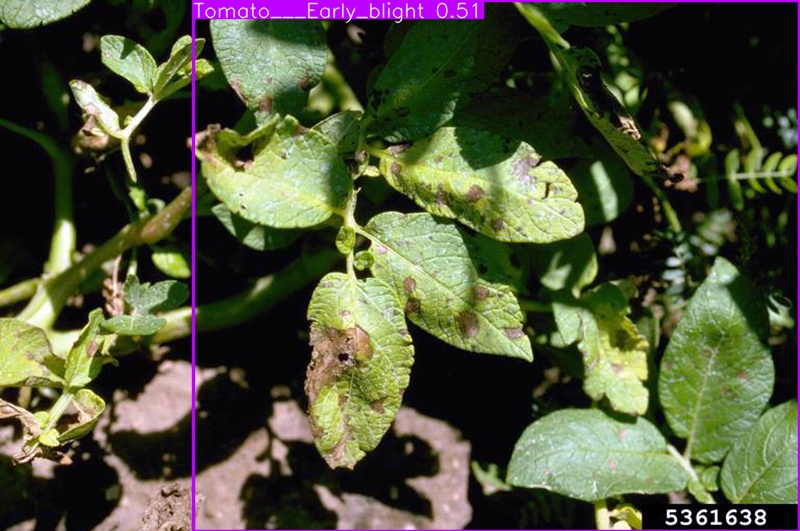

In [9]:
from IPython.display import Image
Image(filename="/content/runs/detect/predict/Early-blight-potato-canopy.jpg")

In [10]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/YOLO_Trainings1/PlantDoc_v13/weights/best.pt")

results = model.predict(
    source="/content/Early-blight-potato-canopy.jpg",
    save=True,
    imgsz=640,
    conf=0.5
)


image 1/1 /content/Early-blight-potato-canopy.jpg: 448x640 3 Potato leaf late blights, 699.8ms
Speed: 4.5ms preprocess, 699.8ms inference, 2.3ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict3


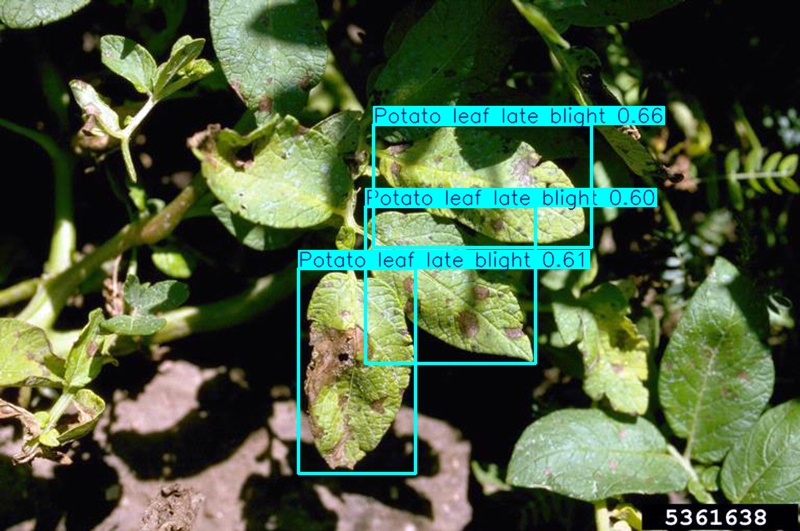

In [11]:
from IPython.display import Image
Image(filename="/content/runs/detect/predict3/Early-blight-potato-canopy.jpg")

In [12]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/YOLO_PlantVillage/train_v1/weights/best.pt")

results = model.predict(
    source="/content/Apple-scab.jpg",
    save=True,
    imgsz=640,
    conf=0.5
)


image 1/1 /content/Apple-scab.jpg: 480x640 (no detections), 153.7ms
Speed: 3.6ms preprocess, 153.7ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict4


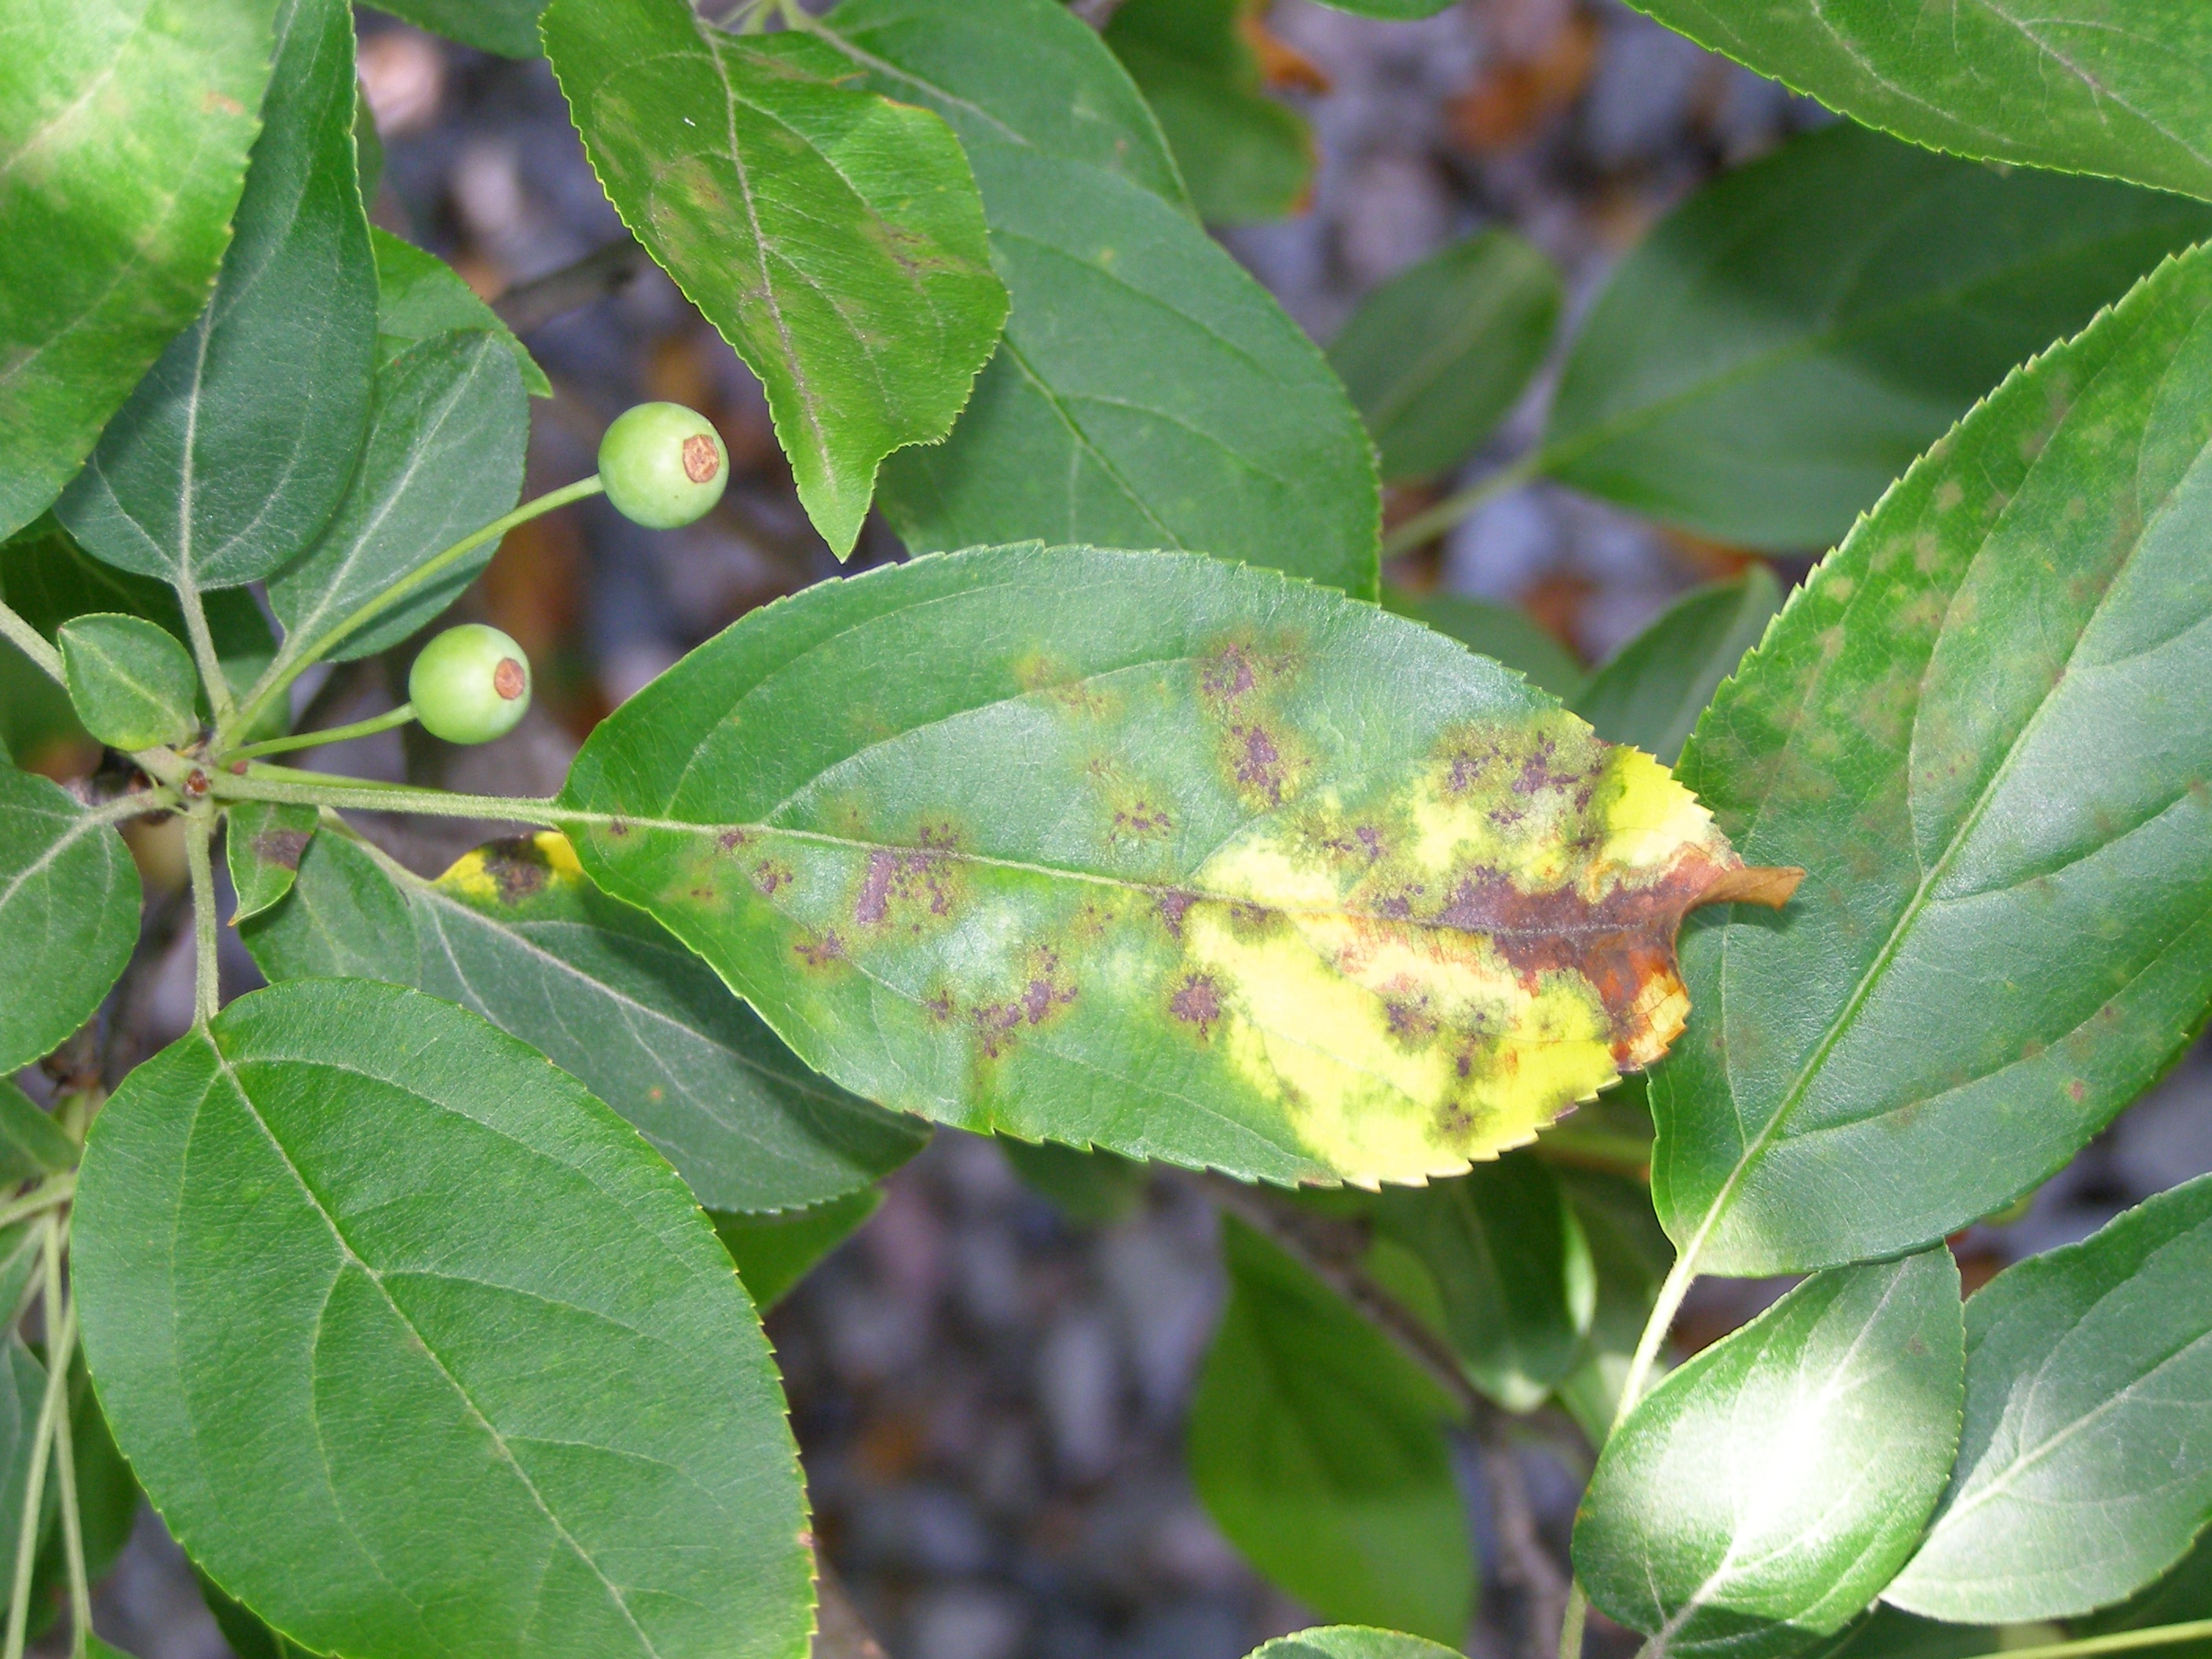

In [14]:
from IPython.display import Image
Image(filename="/content/runs/detect/predict4/Apple-scab.jpg")

In [13]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/YOLO_Trainings1/PlantDoc_v13/weights/best.pt")

results = model.predict(
    source="/content/Apple-scab.jpg",
    save=True,
    imgsz=640,
    conf=0.5
)


image 1/1 /content/Apple-scab.jpg: 480x640 1 Apple Scab Leaf, 1 Apple leaf, 422.1ms
Speed: 3.5ms preprocess, 422.1ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict5


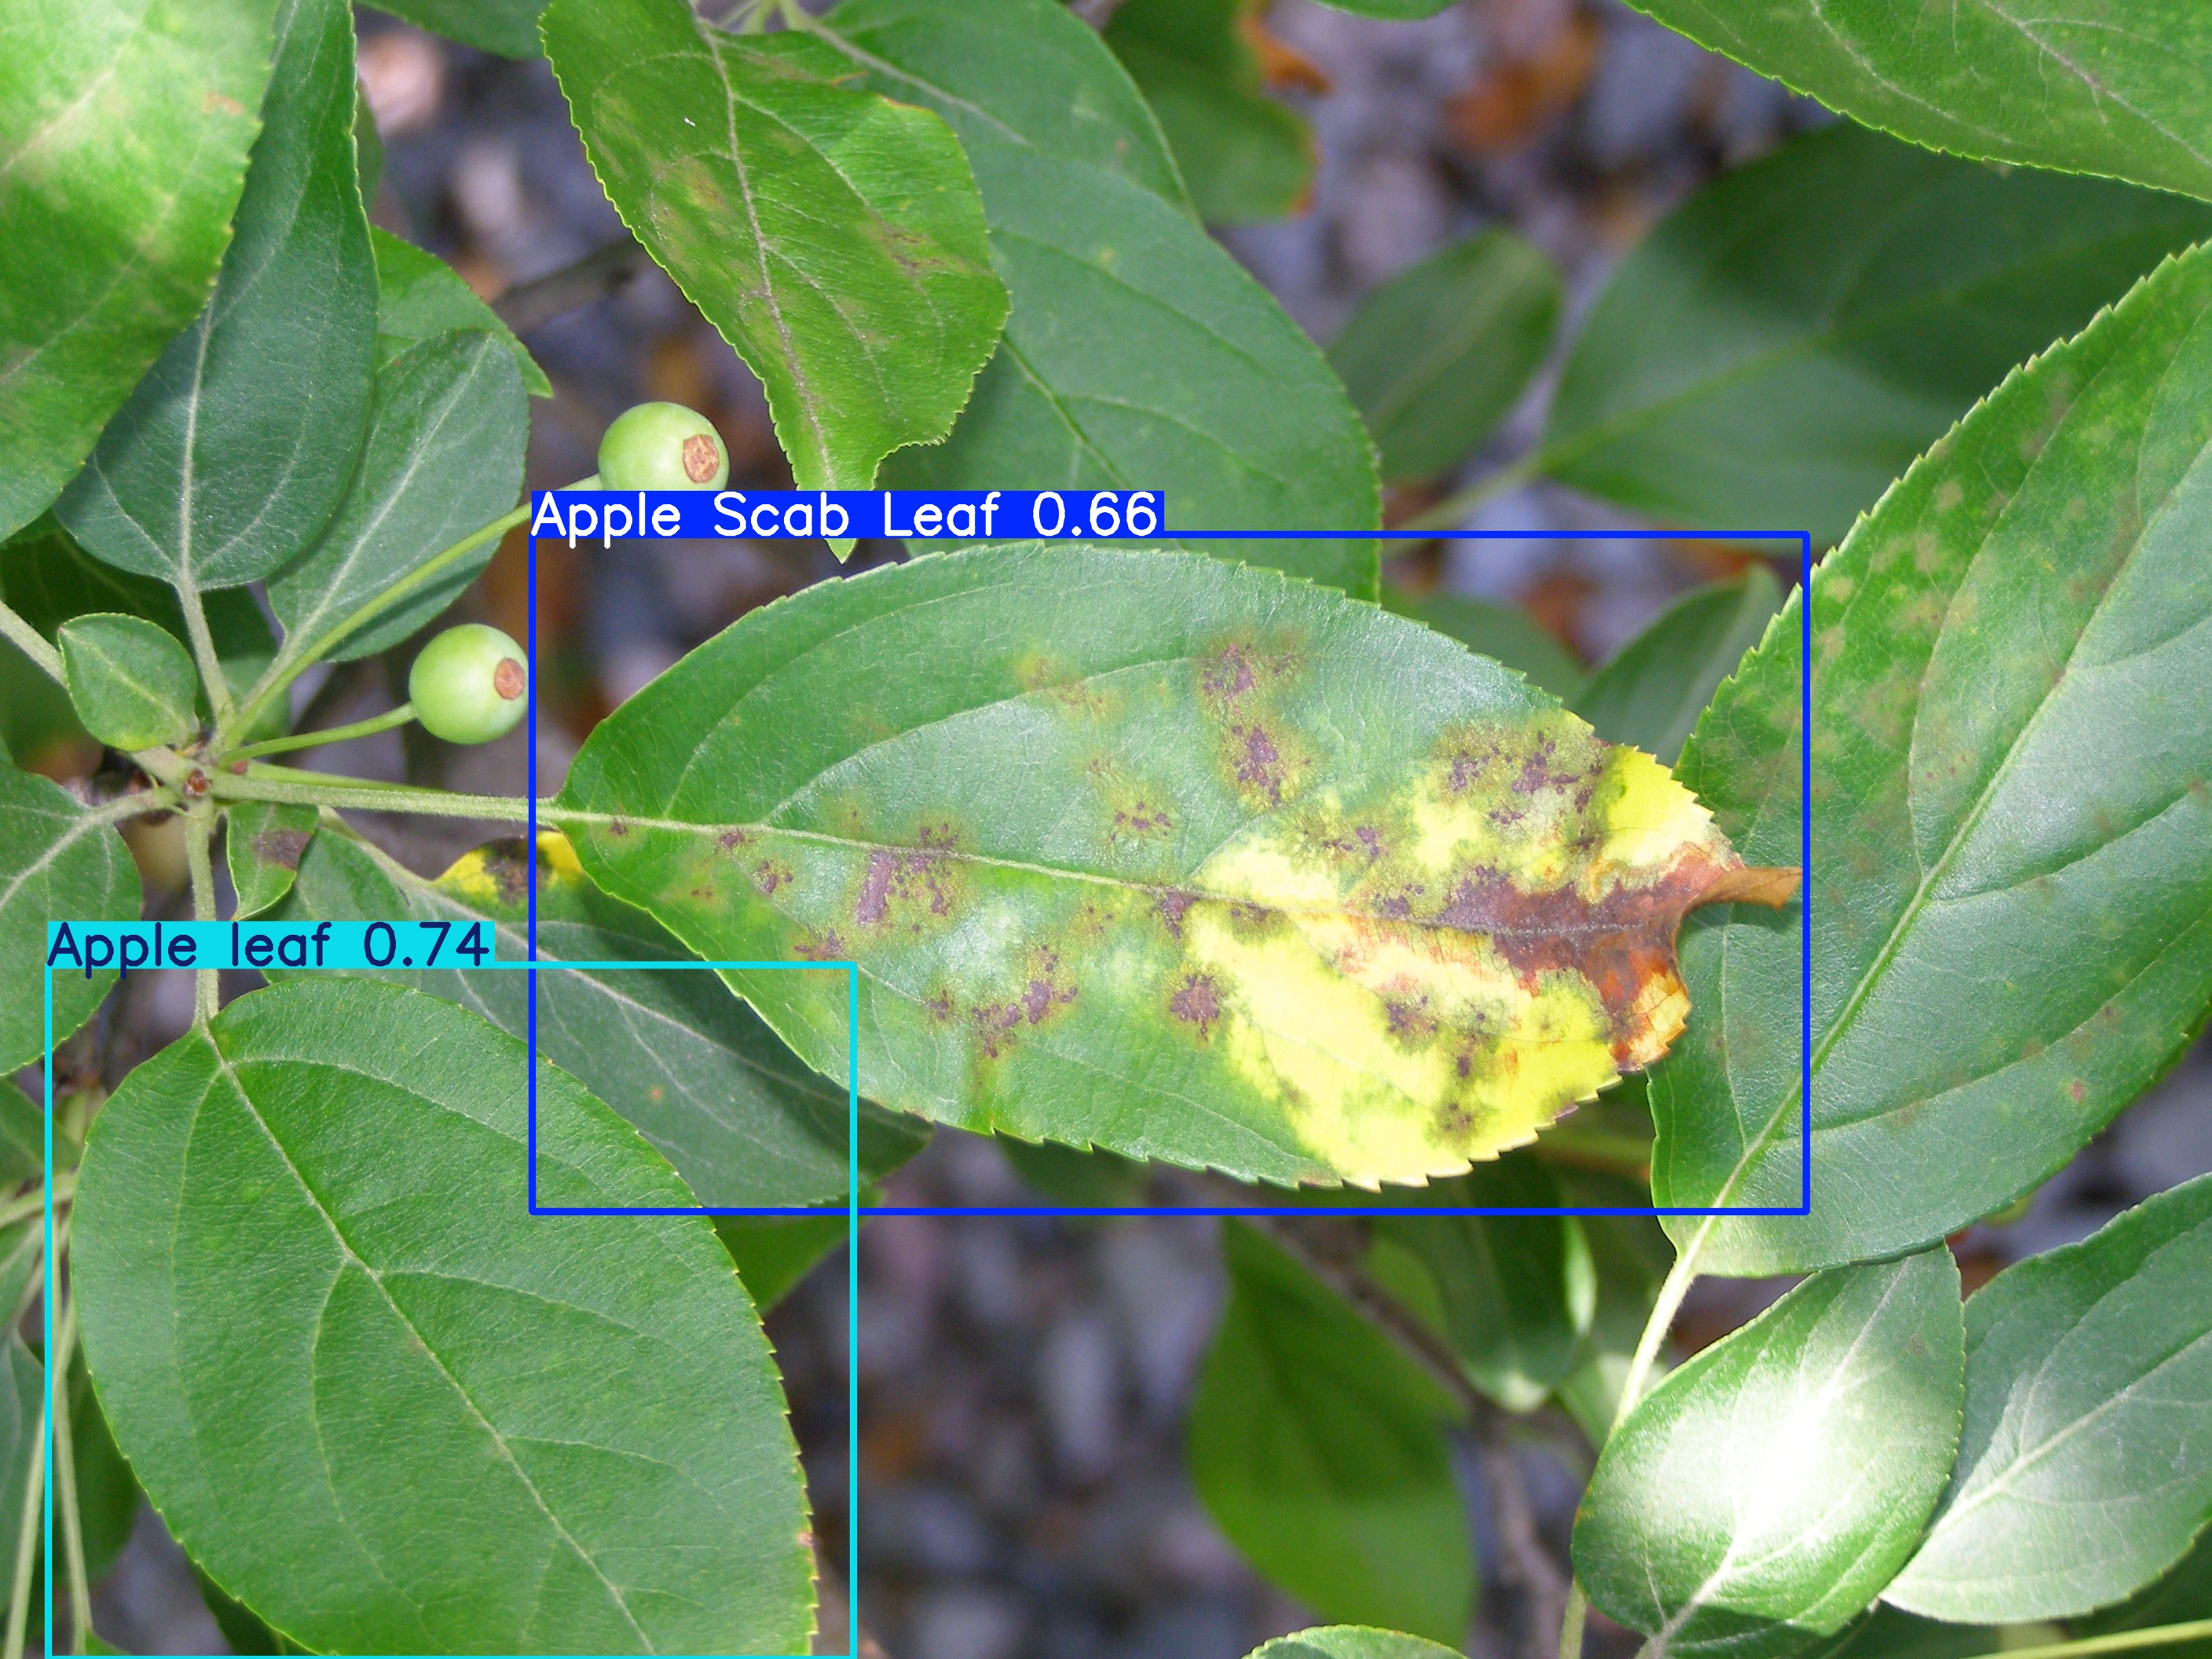

In [15]:
from IPython.display import Image
Image(filename="/content/runs/detect/predict5/Apple-scab.jpg")

In [16]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/YOLO_PlantVillage/train_v1/weights/best.pt")

results = model.predict(
    source="/content/corn-leaf-blight.webp",
    save=True,
    imgsz=640,
    conf=0.5
)


image 1/1 /content/corn-leaf-blight.webp: 448x640 1 Strawberry___Leaf_scorch, 179.1ms
Speed: 4.7ms preprocess, 179.1ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict6


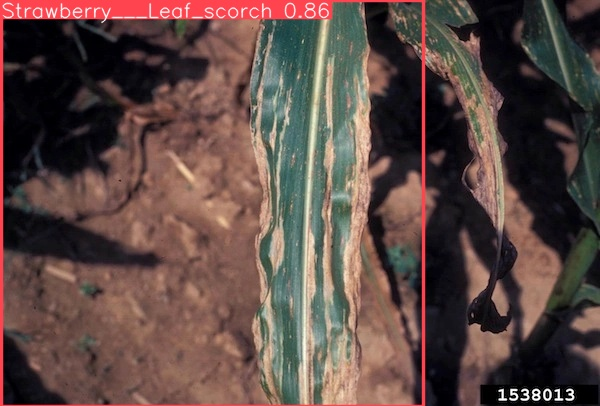

In [19]:
from IPython.display import Image
Image(filename="/content/runs/detect/predict6/corn-leaf-blight.jpg")

In [17]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/YOLO_Trainings1/PlantDoc_v13/weights/best.pt")

results = model.predict(
    source="/content/corn-leaf-blight.webp",
    save=True,
    imgsz=640,
    conf=0.5
)


image 1/1 /content/corn-leaf-blight.webp: 448x640 1 Corn leaf blight, 385.2ms
Speed: 3.9ms preprocess, 385.2ms inference, 1.0ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict7


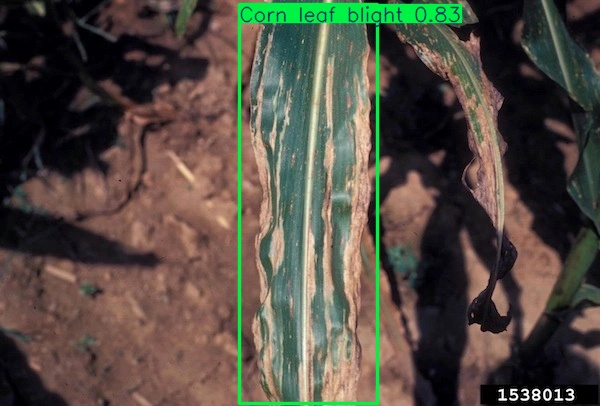

In [20]:
from IPython.display import Image
Image(filename="/content/runs/detect/predict7/corn-leaf-blight.jpg")

In [23]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/YOLO_PlantVillage/train_v1/weights/best.pt")

results = model.predict(
    source="/content/grape leaf black rot.jpg",
    save=True,
    imgsz=640,
    conf=0.5
)


image 1/1 /content/grape leaf black rot.jpg: 448x640 (no detections), 134.5ms
Speed: 3.4ms preprocess, 134.5ms inference, 0.6ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict10


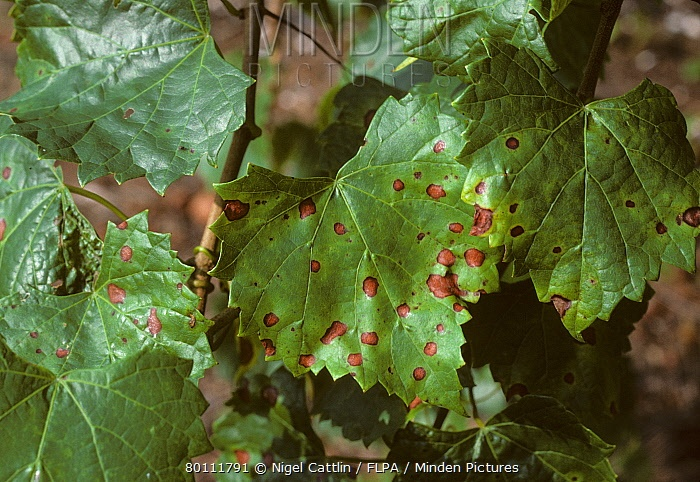

In [25]:
from IPython.display import Image
Image(filename="/content/runs/detect/predict10/grape leaf black rot.jpg")

In [24]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/YOLO_Trainings1/PlantDoc_v13/weights/best.pt")

results = model.predict(
    source="/content/grape leaf black rot.jpg",
    save=True,
    imgsz=640,
    conf=0.5
)


image 1/1 /content/grape leaf black rot.jpg: 448x640 5 grape leafs, 662.3ms
Speed: 6.7ms preprocess, 662.3ms inference, 2.0ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict11


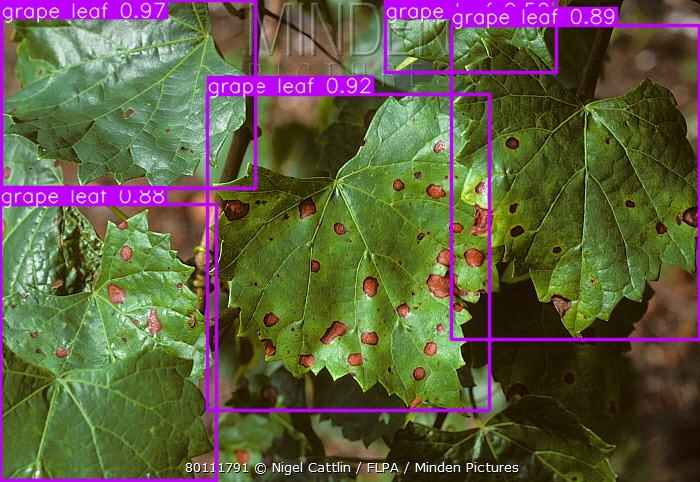

In [26]:
from IPython.display import Image
Image(filename="/content/runs/detect/predict11/grape leaf black rot.jpg")